In [70]:
# Install dependencies if necessary.
%pip install pandas numpy matplotlib seaborn scipy openpyxl

Note: you may need to restart the kernel to use updated packages.


### Imports

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency, kruskal, fisher_exact
from great_tables import GT, md, style, loc
from matplotlib.ticker import MaxNLocator

### Load and clean the metadata

In [72]:
df = pd.read_excel(
    "C:/Users/ryadl/Desktop/EMFIT_local/Emfit/documentation/MS_Metadata.xlsx",
    sheet_name=3
)

df = df.drop(columns=[col for col in df.columns if col.startswith('Unnamed')])
df = df.drop(columns=['Subject'])

df['Age'] = df['Age'].ffill()
df['Male'] = df['Male'].ffill()
df['Onset before 2'] = df['Onset before 2'].ffill()

df = df[~df['subject'].str.contains('V2', na=False)]

df['Group'] = pd.to_numeric(df['Group'], errors='coerce')
df = df.dropna(subset=['Group'])

df['group_label'] = 'Group ' + df['Group'].astype(int).astype(str)

print(df['group_label'].value_counts().sort_index())
print(f"Total: {len(df)} participants")

group_label
Group 1    13
Group 2    36
Group 3    27
Name: count, dtype: int64
Total: 76 participants


### Group subsets and stats tests

In [73]:
# ── Group setup ────────────────────────────────────────────────────────────
df['group_label'] = 'Group ' + df['Group'].astype(int).astype(str)

GROUP_ORDER   = ['Group 1', 'Group 2', 'Group 3']
GROUP_COLOURS = {
    'Group 1': '#E69F00',
    'Group 2': '#56B4E9',
    'Group 3': '#009E73',
}

g1 = df[df['group_label'] == 'Group 1']
g2 = df[df['group_label'] == 'Group 2']
g3 = df[df['group_label'] == 'Group 3']

# Age: Kruskal-Wallis across all three groups
age_stat, age_p = kruskal(
    g1['Age'].dropna(), g2['Age'].dropna(), g3['Age'].dropna()
)

# Gender: Chi-square on 3×2 table
gender_table = pd.crosstab(df['group_label'], df['Male'])
gender_chi2, gender_p, gender_dof, _ = chi2_contingency(gender_table)

# EASI: Mann-Whitney U — Group 1 vs Group 2 only
easi_g1 = pd.to_numeric(g1['EASI'], errors='coerce').dropna()
easi_g2 = pd.to_numeric(g2['EASI'], errors='coerce').dropna()
easi_stat, easi_p = mannwhitneyu(easi_g1, easi_g2, alternative='two-sided')

# Onset before 2: Fisher's exact — Group 1 vs Group 2 only
# (one cell count of 3 confirmed earlier, below chi-square threshold)
onset_table = pd.crosstab(
    df[df['group_label'].isin(['Group 1', 'Group 2'])]['group_label'],
    df[df['group_label'].isin(['Group 1', 'Group 2'])]['Onset before 2'].dropna()
)
onset_OR, onset_p = fisher_exact(onset_table)

print(f"Age:           H={age_stat:.2f}, p={age_p:.4f}  (Kruskal-Wallis)")
print(f"Gender:        chi2={gender_chi2:.2f}, df={gender_dof}, p={gender_p:.4f}  (Chi-square)")
print(f"EASI:          U={easi_stat:.1f}, p={easi_p:.4f}  (Mann-Whitney U)")
print(f"Onset <2 yrs:  OR={onset_OR:.2f}, p={onset_p:.4f}  (Fisher's exact)")
print(f"\nOnset before 2 contingency table:\n{onset_table}")

Age:           H=4.33, p=0.1150  (Kruskal-Wallis)
Gender:        chi2=0.09, df=2, p=0.9583  (Chi-square)
EASI:          U=378.5, p=0.0000  (Mann-Whitney U)
Onset <2 yrs:  OR=0.78, p=1.0000  (Fisher's exact)

Onset before 2 contingency table:
Onset before 2  0.0  1.0
group_label             
Group 1           3   10
Group 2          10   26


### Baseline characterstics table

In [74]:
def fmt_mean_sd(series):
    s = pd.to_numeric(series, errors='coerce').dropna()
    return f"{s.mean():.1f} ± {s.std():.1f}"

def fmt_pct_male(grp):
    col = pd.to_numeric(grp['Male'], errors='coerce').dropna()
    n, k = len(col), int(col.sum())
    return f"{k}/{n} ({k/n*100:.0f}%)"

def fmt_pct_onset(grp):
    col = pd.to_numeric(grp['Onset before 2'], errors='coerce').dropna()
    if len(col) == 0:
        return '—'
    n, k = len(col), int(col.sum())
    return f"{k}/{n} ({k/n*100:.0f}%)"

table_df = pd.DataFrame({
    'Characteristic': ['Age, years', 'Male, n (%)', 'EASI score', 'Onset before age 2, n (%)'],
    'Group 1\n(AD + systemic therapy, n=13)': [
        fmt_mean_sd(g1['Age']),
        fmt_pct_male(g1),
        fmt_mean_sd(g1['EASI']),
        fmt_pct_onset(g1),
    ],
    'Group 2\n(AD, n=36)': [
        fmt_mean_sd(g2['Age']),
        fmt_pct_male(g2),
        fmt_mean_sd(g2['EASI']),
        fmt_pct_onset(g2),
    ],
    'Group 3\n(Control, n=27)': [
        fmt_mean_sd(g3['Age']),
        fmt_pct_male(g3),
        '—',
        '—',
    ],
    'p-value': [
        f'{age_p:.4f}',
        f'{gender_p:.4f}',
        f'{easi_p:.4f}',
        f'{onset_p:.4f}',
    ],
    'Test': [
        'Kruskal-Wallis',
        'Chi-square',
        'Mann-Whitney U †',
        "Fisher's exact †",
    ],
})

(
    GT(table_df)
    .tab_header(
        title='Table 1. Baseline Characteristics by Group',
        subtitle=md('Values are mean ± SD.')
    )
    .tab_source_note(
        md('† Comparison is Group 1 vs Group 2 only; Group 3 (control) has no EASI score or eczema onset data.')
    )
    .cols_label(Characteristic='Characteristic')
    .tab_style(
        style=style.text(weight='bold'),
        locations=loc.column_labels()
    )
    .tab_style(
        style=style.text(weight='bold'),
        locations=loc.header()
    )
    .tab_style(
        style=style.fill(color='#F7F7F7'),
        locations=loc.body(rows=[1, 3])
    )
    .opt_table_font(font='Calibri')
    .opt_horizontal_padding(scale=2)
)

GT(_tbl_data=              Characteristic Group 1\n(AD + systemic therapy, n=13)  \
0                 Age, years                             14.1 ± 1.8   
1                Male, n (%)                             6/13 (46%)   
2                 EASI score                             19.7 ± 7.7   
3  Onset before age 2, n (%)                            10/13 (77%)   

  Group 2\n(AD, n=36) Group 3\n(Control, n=27) p-value              Test  
0          14.4 ± 1.6               15.2 ± 1.6  0.1150    Kruskal-Wallis  
1         16/36 (44%)              13/27 (48%)  0.9583        Chi-square  
2           7.4 ± 6.2                        —  0.0000  Mann-Whitney U †  
3         26/36 (72%)                        —  1.0000  Fisher's exact †  , _body=<great_tables._gt_data.Body object at 0x0000028BD16845D0>, _boxhead=Boxhead([ColInfo(var='Characteristic', type=<ColInfoTypeEnum.default: 1>, column_label='Characteristic', column_align='left', column_width=None), ColInfo(var='Group 1\n(AD + systemic therapy, n=13)', type=<ColInfoTypeEnum.default: 1>, column_label='Group 1\n(AD + systemic therapy, n=13)', column_align='left', column_width=None), ColInfo(var='Group 2\n(AD, n=36)', type=<ColInfoTypeEnum.default: 1>, column_label='Group 2\n(AD, n=36)', column_align='left', column_width=None), ColInfo(var='Group 3\n(Control, n=27)', type=<ColInfoTypeEnum.default: 1>, column_label='Group 3\n(Control, n=27)', column_align='left', column_width=None), ColInfo(var='p-value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='Test', type=<ColInfoTypeEnum.default: 1>, column_label='Test', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000028BD2E4E550>, _spanners=Spanners([]), _heading=Heading(title='Table 1. Baseline Characteristics by Group', subtitle=Md(text='Values are mean ± SD.'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000028BD2163C50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000028BD2162A90>, _source_notes=[Md(text='† Comparison is Group 1 vs Group 2 only; Group 3 (control) has no EASI score or eczema onset data.')], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Characteristic', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Group 1\n(AD + systemic therapy, n=13)', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Group 2\n(AD, n=36)', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Group 3\n(Control, n=27)', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='p-value', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='Test', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)

### Age boxplot

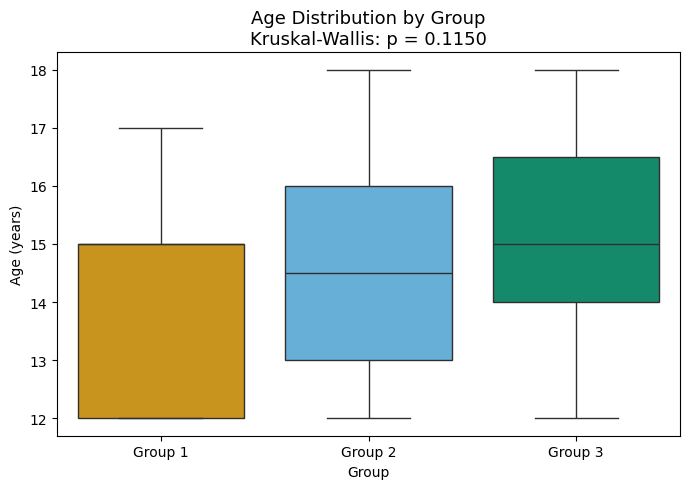

In [75]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df, x='group_label', y='Age',
    order=GROUP_ORDER,
    hue='group_label', palette=GROUP_COLOURS,
    hue_order=GROUP_ORDER, legend=False, ax=ax
)

ax.set_title(f'Age Distribution by Group\nKruskal-Wallis: p = {age_p:.4f}', fontsize=13)
ax.set_xlabel('Group')
ax.set_ylabel('Age (years)')
plt.tight_layout()
plt.show()

### Gender barplot

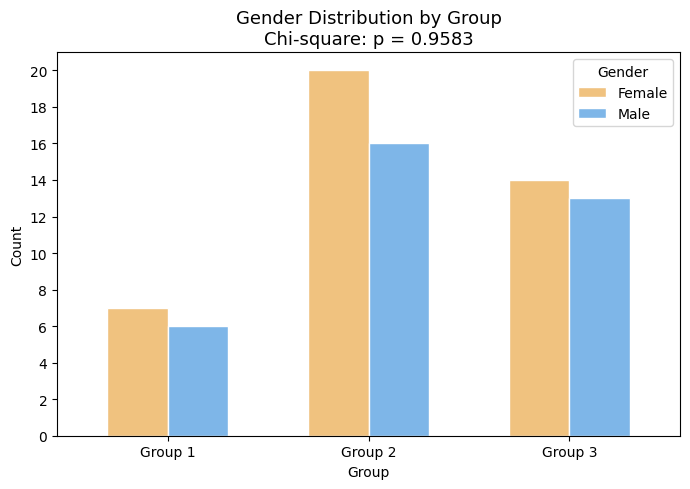

In [76]:
fig, ax = plt.subplots(figsize=(7, 5))

gender_counts = (
    df.groupby(['group_label', 'Male'])
    .size()
    .unstack()
    .reindex(GROUP_ORDER)
)
gender_counts.columns = ['Female', 'Male']
gender_counts.plot(
    kind='bar',
    color=['#F0C27F', '#7EB6E8'],   # neutral female/male colours, not group colours
    ax=ax, edgecolor='white', width=0.6
)

ax.set_title(f'Gender Distribution by Group\nChi-square: p = {gender_p:.4f}', fontsize=13)
ax.set_xlabel('Group')
ax.set_ylabel('Count')
ax.set_xticklabels(GROUP_ORDER, rotation=0)
ax.set_yticks(np.arange(0,22,2))
ax.legend(title='Gender')
plt.tight_layout()
plt.show()

### EASI boxplot

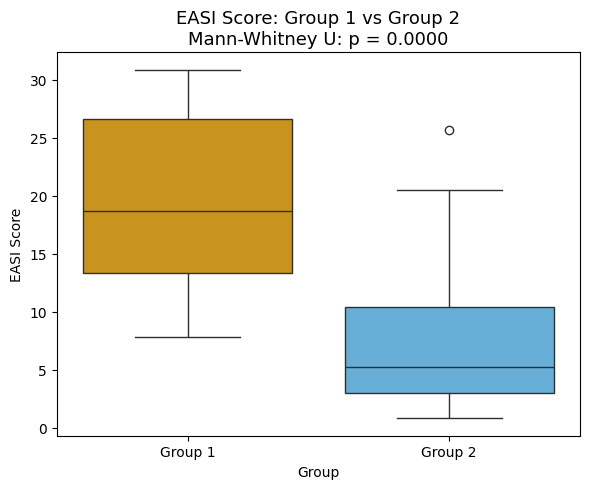

In [77]:
eczema = df[df['group_label'].isin(['Group 1', 'Group 2'])].copy()
eczema['EASI'] = pd.to_numeric(eczema['EASI'], errors='coerce')

fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(
    data=eczema, x='group_label', y='EASI',
    order=['Group 1', 'Group 2'],
    hue='group_label', palette=GROUP_COLOURS,
    hue_order=['Group 1', 'Group 2'], legend=False, ax=ax
)

ax.set_title(
    f'EASI Score: Group 1 vs Group 2\nMann-Whitney U: p = {easi_p:.4f}',
    fontsize=13
)
ax.set_xlabel('Group')
ax.set_ylabel('EASI Score')
plt.tight_layout()
plt.show()

## Atopic comorbidity by group

In [78]:
print(df.columns.tolist())

['subject', 'Group', 'EASI', 'Male', 'Age', 'Age (MRI)', 'Onset before 2', 'group_label']


Total unique participants: 76
group_label
Group 2    36
Group 3    27
Group 1    13
Name: count, dtype: int64


KeyError: 'Asthma'

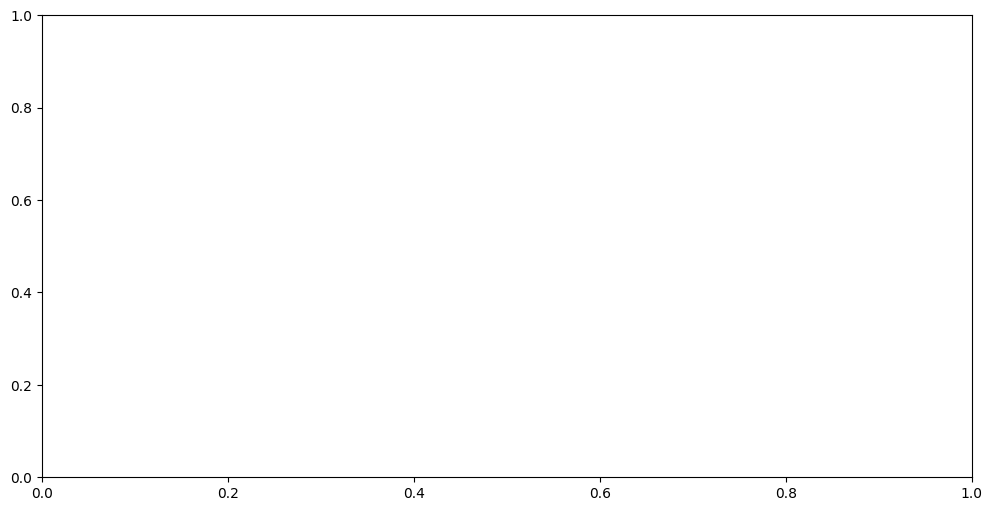

In [79]:
# === Baseline: Atopic comorbidities by group ===
import matplotlib.ticker as mticker

comorbidity_cols = ['Asthma', 'Hayfever', 'Food allergies', 'Contact allergies']

# === Deduplicate to one row per participant ===
# For multi-visit participants (e.g. MS4V1, MS4V2), take the first visit row only
# so each individual is counted once regardless of how many visits they have
dedup_df = df.drop_duplicates(subset='subject').copy()

print(f"Total unique participants: {len(dedup_df)}")
print(dedup_df['group_label'].value_counts())

# === Figure 1: Prevalence of each comorbidity by group (% with raw count on bar) ===
fig1, ax1 = plt.subplots(figsize=(12, 6))

x = np.arange(len(comorbidity_cols))
n_groups = len(GROUP_ORDER)
bar_width = 0.22
offsets = np.linspace(-(n_groups - 1) / 2, (n_groups - 1) / 2, n_groups) * bar_width

for offset, group in zip(offsets, GROUP_ORDER):
    group_data = dedup_df[dedup_df['group_label'] == group]
    n_group = len(group_data)
    pcts = []
    counts = []
    for col in comorbidity_cols:
        n_yes = (group_data[col].str.lower() == 'yes').sum()
        pcts.append(100 * n_yes / n_group if n_group > 0 else 0)
        counts.append(n_yes)

    bars = ax1.bar(x + offset, pcts, width=bar_width, label=group,
                   color=GROUP_PALETTE[group], alpha=0.85,
                   edgecolor='black', linewidth=0.5)

    # Raw count label on each bar
    for bar, count, pct in zip(bars, counts, pcts):
        if pct > 0:
            ax1.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 1,
                     str(count), ha='center', va='bottom', fontsize=8)

ax1.set_xticks(x)
ax1.set_xticklabels(comorbidity_cols, fontsize=10)
ax1.set_ylabel('Participants with comorbidity (%)')
ax1.set_title('Atopic comorbidity prevalence by group')
ax1.set_ylim(0, 110)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter())
ax1.legend(title='Group', fontsize=9)
plt.tight_layout()
plt.show()


# === Figure 2: Number of comorbidities per participant by group (stacked % bar) ===
fig2, ax2 = plt.subplots(figsize=(8, 6))

# Count comorbidities per participant
dedup_df['comorbidity_count'] = dedup_df[comorbidity_cols].apply(
    lambda row: (row.str.lower() == 'yes').sum(), axis=1
)

count_levels = [0, 1, 2, 3, 4]
count_colors = ['#d3d3d3', '#fee8c8', '#fdbb84', '#e34a33', '#b30000']
count_labels = ['0', '1', '2', '3', '4']

x_pos = np.arange(len(GROUP_ORDER))
bottoms = np.zeros(len(GROUP_ORDER))

for level, color, label in zip(count_levels, count_colors, count_labels):
    pcts = []
    for group in GROUP_ORDER:
        group_data = dedup_df[dedup_df['group_label'] == group]
        n_group = len(group_data)
        n_level = (group_data['comorbidity_count'] == level).sum()
        pcts.append(100 * n_level / n_group if n_group > 0 else 0)

    bars = ax2.bar(x_pos, pcts, bottom=bottoms, color=color,
                   label=f'{label} comorbidities', edgecolor='black', linewidth=0.5)

    # Label each segment if large enough to read
    for bar, pct, bottom in zip(bars, pcts, bottoms):
        if pct >= 5:
            ax2.text(bar.get_x() + bar.get_width() / 2,
                     bottom + pct / 2,
                     f'{pct:.0f}%', ha='center', va='center',
                     fontsize=8, color='black')
    bottoms += np.array(pcts)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(GROUP_ORDER, fontsize=10)
ax2.set_ylabel('Percentage of participants (%)')
ax2.set_title('Number of atopic comorbidities by group')
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.legend(title='Comorbidity count', fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()